In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json

df = pd.read_csv('data/SMRT_features_v2.csv')

# All columns except pubchem and rt are features
FEATURES = [c for c in df.columns if c not in ['pubchem', 'rt']]
TARGET = 'rt'

X = df[FEATURES]
y = df[TARGET]

print("Dataset shape:", X.shape)
print("Number of features:", len(FEATURES))
print("Any nulls:", X.isnull().sum().sum())
print("\nFirst 3 feature names:", FEATURES[:3])
print("Last 3 feature names:", FEATURES[-3:])

Dataset shape: (77901, 137)
Number of features: 137
Any nulls: 0

First 3 feature names: ['mol_weight', 'logp', 'hbd']
Last 3 feature names: ['fp_125', 'fp_126', 'fp_127']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train_sc.shape[0]}")
print(f"Test size:  {X_test_sc.shape[0]}")

Train size: 62320
Test size:  15581


In [14]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Model 1: Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=1
)

# Model 2: Random Forest (faster to train)
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,      # uses all CPU cores
    verbose=1
)

print("Training Random Forest first (faster)...")
rf_model.fit(X_train_sc, y_train)
rf_pred = rf_model.predict(X_test_sc)
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest  →  R²: {rf_r2:.4f}  |  RMSE: {rf_rmse:.2f}s")

print("\nTraining Gradient Boosting (slower)...")
gb_model.fit(X_train_sc, y_train)
gb_pred = gb_model.predict(X_test_sc)
gb_r2   = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"Gradient Boost →  R²: {gb_r2:.4f}  |  RMSE: {gb_rmse:.2f}s")

# Pick the better model
if gb_r2 >= rf_r2:
    best_model = gb_model
    best_name  = "Gradient Boosting"
    best_r2    = gb_r2
    best_rmse  = gb_rmse
else:
    best_model = rf_model
    best_name  = "Random Forest"
    best_r2    = rf_r2
    best_rmse  = rf_rmse

print(f"\nBest model: {best_name}")
print(f"R²:   {best_r2:.4f}")
print(f"RMSE: {best_rmse:.2f} seconds")

Training Random Forest first (faster)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   46.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   52.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished


Random Forest  →  R²: 0.7056  |  RMSE: 94.59s

Training Gradient Boosting (slower)...
      Iter       Train Loss   Remaining Time 
         1       29498.7517            4.52m
         2       28545.3480            4.34m
         3       27680.9585            4.39m
         4       26871.3018            4.42m
         5       26147.6092            4.29m
         6       25457.9902            4.16m
         7       24835.4754            4.07m
         8       24265.8643            4.01m
         9       23730.5509            3.95m
        10       23233.5058            3.90m
        20       19751.6740            3.64m
        30       17780.3563            3.44m
        40       16460.1290            3.30m
        50       15508.6935            3.19m
        60       14766.7206            3.05m
        70       14145.5541            2.90m
        80       13636.2516            2.76m
        90       13190.7701            2.62m
       100       12819.6127            2.49m
       200   

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.2s finished


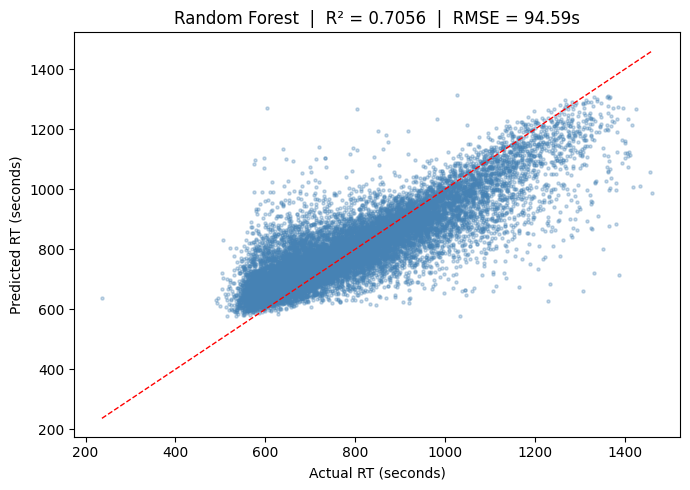

In [15]:
y_pred = best_model.predict(X_test_sc)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel('Actual RT (seconds)')
plt.ylabel('Predicted RT (seconds)')
plt.title(f'{best_name}  |  R² = {best_r2:.4f}  |  RMSE = {best_rmse:.2f}s')
plt.tight_layout()
plt.savefig('data/model_performance.png', dpi=150)
plt.show()

In [16]:
joblib.dump(model,  'models/rt_predictor.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.
